# AdaBoost (Stochastic) — Binary Classification

---

## 1. Problem Setup

Assume we have a binary classification dataset:

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D, \quad y_i \in \{-1, +1\}
$$

The goal is to learn a strong classifier by combining multiple weak learners.

---

## 2. Key Idea

AdaBoost builds an ensemble of weak learners sequentially, where:

- Each model focuses more on previously misclassified samples  
- Final prediction is a weighted combination of all models  

This implementation is **Stochastic AdaBoost**, where:

- Training data is sampled according to weights at each iteration  

---

## 3. Initialization

Initialize sample weights uniformly:

$$
w_i^{(1)} = \frac{1}{N}
$$

---

## 4. Weighted Sampling (Stochastic Step)

At iteration $m$, sample data points with replacement:

$$
\mathcal{D}^{(m)} \sim \text{Multinomial}(w^{(m)})
$$

This introduces stochasticity compared to standard AdaBoost.

---

## 5. Train Weak Learner

Train a weak classifier $h_m(x)$ on the sampled dataset.

---

## 6. Weighted Error

Compute weighted classification error:

$$
\epsilon_m = \sum_{i=1}^{N} w_i^{(m)} \cdot \mathbf{1}(y_i \neq h_m(x_i))
$$

To ensure numerical stability:

$$
\epsilon_m \in (10^{-10}, 1 - 10^{-10})
$$

---

## 7. Model Weight

Compute importance of the weak learner:

$$
\alpha_m = \frac{1}{2} \log \left( \frac{1 - \epsilon_m}{\epsilon_m} \right)
$$

---

## 8. Weight Update Rule

Update sample weights:

$$
w_i^{(m+1)} = w_i^{(m)} \cdot \exp(-\alpha_m y_i h_m(x_i))
$$

Normalize weights:

$$
w_i^{(m+1)} = \frac{w_i^{(m+1)}}{\sum_{j=1}^{N} w_j^{(m+1)}}
$$

---

## 9. Special Cases

- If $\epsilon_m = 0$:
  
$$
\alpha_m \to \infty
$$

This corresponds to a perfect classifier → stop early.

- If $\epsilon_m \ge 0.5$:

Model is discarded (worse than random guessing).

---

## 10. Final Prediction

Aggregate predictions:

$$
F(x) = \sum_{m=1}^{M} \alpha_m h_m(x)
$$

Final class prediction:

$$
\hat{y} = \text{sign}(F(x))
$$

---

## 11. Algorithm Summary

Initialize weights:

$$
w_i = \frac{1}{N}
$$

For $m = 1$ to $M$:

$$
\text{Sample data using } w_i
$$

$$
\text{Train weak learner } h_m(x)
$$

$$
\epsilon_m = \sum w_i \mathbf{1}(y_i \neq h_m(x_i))
$$

$$
\alpha_m = \frac{1}{2} \log \frac{1 - \epsilon_m}{\epsilon_m}
$$

$$
w_i \leftarrow w_i \exp(-\alpha_m y_i h_m(x_i))
$$

$$
\text{Normalize } w_i
$$

---

## 12. Optimization Perspective

AdaBoost minimizes the exponential loss:

$$
\mathcal{L} = \sum_{i=1}^{N} \exp(-y_i F(x_i))
$$

where:

$$
F(x) = \sum_{m=1}^{M} \alpha_m h_m(x)
$$

---

## 13. Key Properties

- Converts weak learners into a strong classifier  
- Focuses on hard samples via weight updates  
- Stochastic sampling adds randomness → can improve generalization  
- Sensitive to noise and outliers  

---

## 14. Final Insight

Stochastic AdaBoost introduces randomness via sampling:

$$
\text{Deterministic AdaBoost} \rightarrow \text{Weighted training}
$$

$$
\text{Stochastic AdaBoost} \rightarrow \text{Weighted sampling + training}
$$

This makes the model closer in spirit to bagging + boosting combined.

---

In [1]:
class LeafNode:
    """
    Leaf node of the decision tree.

    Attributes
    ----------
    value : int, float
        The predicted class label (for classification) or value (for regression)
        at the leaf.
    """
    def __init__(self, value):
        self.value = value

In [2]:
class DecisionNode:
    """
    Internal decision node of the tree.

    Attributes
    ----------
    best_feature : int
        Index of the feature used for the split.
    best_threshold : float
        Threshold value for splitting.
    left_child : LeafNode or DecisionNode
        Left subtree (samples <= threshold).
    right_child : LeafNode or DecisionNode
        Right subtree (samples > threshold).
    """
    def __init__(self, best_feature, best_threshold, left_child, right_child):
        self.best_feature = best_feature
        self.best_threshold = best_threshold
        self.left_child = left_child
        self.right_child = right_child

In [3]:
class DecisionTreeClassifier:
    """
    Decision Tree Classifier using recursive binary splits.

    Parameters
    ----------
    max_depth : int
        Maximum depth of the tree.
    min_samples_split : int
        Minimum number of samples required to split a node.
    scoring : str
        Impurity measure: 'gini' for Gini index, 'entropy' for Information Gain.
    feature_fraction : float
        Fraction of features to consider at each split (for random feature selection).

    Attributes
    ----------
    root : DecisionNode or LeafNode
        Root node of the trained tree.
    """
    def __init__(self, max_depth=10, min_samples_split=1, scoring='gini', feature_fraction=1.0):
  
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction
        self.root = None

        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")

    def _stopping_condition(self, data, depth):
        """
        Check whether to stop splitting the current node.

        Stopping criteria:
        - Maximum depth reached
        - Not enough samples to split
        - Node is pure (all labels identical)
        """
        if depth >= self.max_depth:
            return True
        if len(data) < self.min_samples_split:
            return True
        if len(np.unique(data[:, -1])) == 1:
            return True
        return False

    def _score(self, left, right):
        """
        Compute the impurity score of a potential split.

        Parameters
        ----------
        left : np.array
            Labels in the left split.
        right : np.array
            Labels in the right split.

        Returns
        -------
        float
            Weighted impurity score of the split (lower is better).
        """
        n_left = len(left)
        n_right = len(right)
        
        # Avoid invalid splits
        if n_left == 0 or n_right == 0:
            return np.inf
            
        total = n_left + n_right

        counts_left = np.unique(left, return_counts=True)[1]
        counts_right = np.unique(right, return_counts=True)[1]

        probability_left = counts_left / np.sum(counts_left)
        probability_right = counts_right / np.sum(counts_right)

        if self.scoring == 'gini':
            score_left = 1 - np.sum(probability_left**2)
            score_right = 1 - np.sum(probability_right**2)
        # entropy    
        else:  
            score_left = -np.sum(probability_left * np.log(probability_left))
            score_right = -np.sum(probability_right * np.log(probability_right))
            
        # Weighted average of left and right impurity
        return (n_left * score_left + n_right * score_right) / total

    def _random_feature(self, data):
        """
        Randomly select a subset of features based on feature_fraction.

        Returns
        -------
        selected_features : np.array
            Indices of selected features for splitting.
        """  
        n_features = data.shape[1] - 1  # exclude target
        
        n_selected = max(1, int(round(n_features * self.feature_fraction)))
        
        selected_features = np.random.choice(n_features, n_selected, replace=False)
        
        return selected_features

    def _find_all_threshold(self, data, selected_features):
        """
        Compute all candidate thresholds for each selected feature.

        Returns
        -------
        list of np.array
            Candidate threshold values for each feature.
        """
        all_thresholds = []
        for feature in selected_features:
            unique_vals = np.unique(data[:, feature])
            if len(unique_vals) <= 1:
                all_thresholds.append(np.array([]))
            else:
                # Midpoints between successive values
                successive_average = (unique_vals[1:] + unique_vals[:-1]) / 2
                all_thresholds.append(successive_average)
                
        return all_thresholds

    def _split(self, data, feature, threshold):
        """
        Split data into left and right subsets based on threshold.

        Parameters
        ----------
        data : np.array
        feature : int
        threshold : float

        Returns
        -------
        left : np.array
        right : np.array
        """
        condition = data[:, feature] <= threshold
        
        return data[condition], data[~condition]

    def _best_feature_threshold(self, data, selected_features, all_thresholds):
        """
        Find the best feature and threshold combination minimizing impurity.

        Returns
        -------
        best_feature : int
        best_threshold : float
        """
        best_score = np.inf
        best_feature = None
        best_threshold = None

        for i, feature in enumerate(selected_features):
            thresholds = all_thresholds[i]
            if len(thresholds) == 0:
                continue
            for threshold in thresholds:
                left, right = self._split(data, feature, threshold)
                score = self._score(left[:, -1], right[:, -1])
                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _find_best_split(self, data):
        """
        Function to select features, compute thresholds and find best split.
        """
        selected_features = self._random_feature(data)
        
        all_thresholds = self._find_all_threshold(data, selected_features)
        
        best_feature, best_threshold = self._best_feature_threshold(data, selected_features, all_thresholds)
        
        return best_feature, best_threshold

    def _build_tree(self, data, depth):
        """
        Recursively build the decision tree.

        Returns
        -------
        LeafNode or DecisionNode
        """
        if self._stopping_condition(data, depth):
            # Leaf prediction: majority class
            prediction = stats.mode(data[:, -1])[0]
            return LeafNode(prediction)

        best_feature, best_threshold = self._find_best_split(data)
        left_data, right_data = self._split(data, best_feature, best_threshold)

        # If no valid split found, create leaf
        if best_feature is None:
            prediction = stats.mode(data[:, -1])[0]
            return LeafNode(value=prediction)

        left_child = self._build_tree(left_data, depth + 1)
        right_child = self._build_tree(right_data, depth + 1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self, X, y):
        """
        Fit the decision tree to the training data.

        Parameters
        ----------
        X : np.array
            Feature matrix (N x D)
        y : np.array
            Labels vector (N,)
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        data = np.column_stack((X, y))
        self.root = self._build_tree(data, 0)

    def _predict_single(self, x, node):
        """
        Predict label for a single sample recursively.

        Parameters
        ----------
        x : np.array
            Feature vector
        node : DecisionNode or LeafNode

        Returns
        -------
        predicted label
        """
        if isinstance(node, LeafNode):
            return node.value
        if x[node.best_feature] <= node.best_threshold:
            return self._predict_single(x, node.left_child)
        else:
            return self._predict_single(x, node.right_child)

    def predict(self, X):
        """
        Predict labels for multiple samples.

        Parameters
        ----------
        X : np.array
            Feature matrix

        Returns
        -------
        np.array
            Predicted labels
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.array([self._predict_single(x, self.root) for x in X])

In [4]:
class AdaBoostClassifier:
    """
    AdaBoost Classifier using Decision Trees as weak learners.

    Parameters
    ----------
    n_estimators : int, default=100
        Number of boosting rounds.

    max_depth : int, default=1
        Maximum depth of each weak learner (decision tree).

    min_samples_split : int, default=1
        Minimum samples required to split a node.

    scoring : str, default='gini'
        Splitting criterion for decision trees.

    feature_fraction : float, default=1.0
        Fraction of features used for each tree.

    Attributes
    ----------
    all_models : list
        List of trained weak learners.

    alpha : list
        Weight assigned to each weak learner.
    """
    def __init__(self,n_estimators=100, max_depth=1, min_samples_split=1, scoring='gini', feature_fraction=1.0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring= scoring
        self.feature_fraction = feature_fraction

        # Validate
        if type(self.n_estimators) != int or self.max_depth <= 0:
            raise ValueError('N estimators must be a positive integer')        
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        
        self.all_models =[]
        self.alpha =[]
        self.weights_history =None
        self.all_weights =[]

    def _weighted_error(self,sample_weights,y_true,y_pred):
        """
        Compute weighted classification error.

        Parameters
        ----------
        sample_weights : np.array
            Current weights of samples.

        y_true : np.array
            True labels (-1, +1).

        y_pred : np.array
            Predicted labels.

        Returns
        -------
        float
            Weighted error (epsilon_m)
        """
        mask = y_true!=y_pred
        eps_m = np.sum(sample_weights[mask])
        
        # Avoid division by zero or log instability
        eps_m = np.clip(eps_m, 1e-10, 1-1e-10)
        return eps_m

    def _compute_model_weight(self,eps_m):
        """
        Compute model weight (alpha_m).

        Formula:
        alpha_m = 0.5 * log((1 - eps_m) / eps_m)
        """
        value = (1-eps_m)/eps_m
        alpha_m = 0.5 * np.log(value)

        return alpha_m

    def _weighted_sampling(self,weights,N):
        """
        Compute model weight (alpha_m).

        Formula:
        alpha_m = 0.5 * log((1 - eps_m) / eps_m)
        """
        sampled_indices = np.random.choice(N,N,replace=True,p=weights)
        
        return sampled_indices


    def fit(self,X,y):
        """
        Fit the AdaBoost to the training data.

        Parameters
        ----------
        X : np.array
            Feature matrix (N x D)
        y : np.array
            Labels vector (N,)
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        y = np.where(y==0,-1,y)
        
        N = len(X)
        
        weights = np.array([1/N]*N)
        self.all_weights.append(weights.copy())

        for m in range(self.n_estimators):
            # Weighted sampling
            sampled_indices = self._weighted_sampling(weights,N)
            X_sampled , y_sampled = X[sampled_indices] , y[sampled_indices]

            # Train weak learner
            model = DecisionTreeClassifier(max_depth=self.max_depth, min_samples_split=self.min_samples_split, 
                                           scoring=self.scoring, feature_fraction=self.feature_fraction)

            model.fit(X_sampled,y_sampled)
            
            # Predictions on full data
            y_pred = model.predict(X)

            # Compute weighted error
            eps_m = self._weighted_error(weights,y,y_pred)

            # Perfect classifier case
            if eps_m ==0:
                print("Perfect Classifier, hence stopping early")
                alpha_m = 1e25
                self.all_models.append(model)
                self.alpha.append(alpha_m)
                break
                
            # Skip weak learner worse than random
            if eps_m >=0.5:
                continue
            
            # Compute model weight
            alpha_m = self._compute_model_weight(eps_m)
            self.all_models.append(model)
            self.alpha.append(alpha_m)

            # Update sample weights
            weights *= np.exp(- alpha_m * y * y_pred)

            weights /=np.sum(weights)
            self.all_weights.append(weights.copy())

        self.weights_history = np.array(self.all_weights)

    def predict(self,X):
        """
        Predict labels for multiple samples.

        Parameters
        ----------
        X : np.array
            Feature matrix

        Returns
        -------
        np.array
            Predicted labels
        """
        # Aggregate weighted predictions
        y_pred = np.zeros(X.shape[0])
        for alpha, model in zip(self.alpha, self.all_models):
            y_pred += alpha * model.predict(X)

        return np.where(y_pred>=0,1,-1)

# Sample Weight Evolution in Stochastic AdaBoost (Heatmap)

This process is to visualize **how sample weights evolve** in a **Stochastic AdaBoost** classifier using a **heatmap**, providing a clear view of the focus of the model on difficult points over iterations.

## 1. Dataset

- Synthetic binary classification data with $N = 200$ samples and $D = 3$ features.
- Labels generated via a logistic model with Gaussian noise.
---
## 2. Model 

- **Weak learner:** Decision tree (max depth = 2) 
- **Number of estimators:** 5  
- **Sampling:** Stochastic weighted resampling  

> Note: Although `n_estimators` = 5, the heatmap includes **6 iterations**, including the **initial uniform weights**.
---
## 3. Heatmap Visualization

- **X-axis:** Sample index  
- **Y-axis:** Iteration (0 = initial weights)  
- **Color intensity:** Magnitude of sample weight  
---

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Binary data
np.random.seed(42)
N = 200  # total samples
D = 3    # features

X = np.random.randn(N, D)
coef = np.random.randn(D, 1)
logits = X @ coef + 0.5 * np.random.randn(N, 1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

p = sigmoid(logits)
y = (p > 0.5).astype(int).reshape(-1)

In [20]:
# Model
clf = AdaBoostClassifier(n_estimators=5, max_depth=2)
clf.fit(X, y)

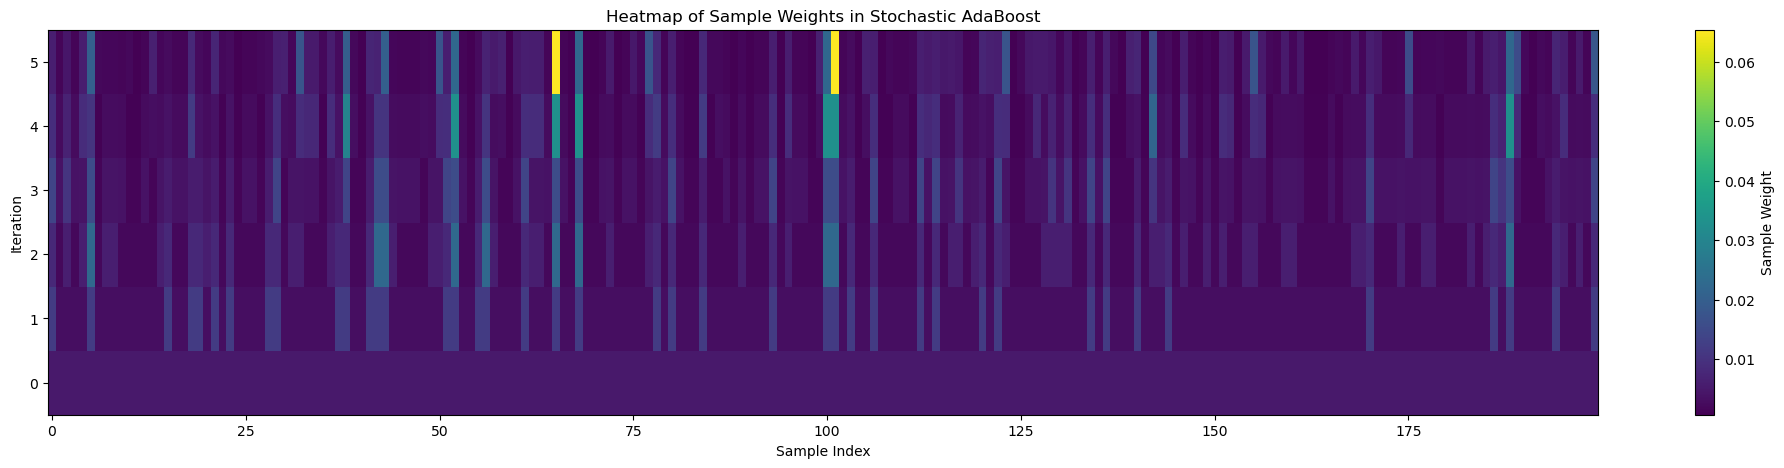

In [21]:
# Plot weights evolution
weights_matrix = clf.weights_history 

plt.figure(figsize=(25,5))
plt.imshow(weights_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='Sample Weight')
plt.xlabel('Sample Index')
plt.ylabel('Iteration')
plt.title('Heatmap of Sample Weights in Stochastic AdaBoost')
plt.yticks(ticks=np.arange(weights_matrix.shape[0]), labels=np.arange(weights_matrix.shape[0]))
plt.gca().invert_yaxis()
plt.show()

---
## 4. Observations

1. **Initial uniform weights:** All samples have equal weight in iteration 0.  
2. **Increasing weights:** Misclassified or hard-to-classify samples show higher intensity (brighter color), indicating higher importance in the next iteration.  
3. **Easily classified samples:** Remain darker (lower weight) throughout iterations.  
4. **Adaptive focus:** The heatmap clearly shows the **adaptive nature of AdaBoost**, emphasizing difficult samples as boosting progresses.
---
## 5. Conclusion

- Heatmap representation makes it easy to identify which samples are difficult for the model.  
- Stochastic AdaBoost adaptively increases the weight of hard points, guiding weak learners to focus on them in subsequent iterations.  
- Visualizing weights as a heatmap provides an intuitive understanding of AdaBoost's sample reweighting mechanism.
---